In [ ]:
!pip install --user torch==2.8 transformers==4.57.1 datasets==4.0 torchvision==0.23.0

In [ ]:
!pip install rouge

In [ ]:
!pip install -U sentence-transformers

In [8]:
import torch
import datasets
from rouge import Rouge 
from sentence_transformers import SentenceTransformer, util
from transformers import pipeline
import matplotlib.pyplot as plt
import numpy as np

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [5]:
# Load model
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
summarizer = pipeline("summarization", model="facebook/bart-large-cnn")

Device set to use mps:0


In [6]:
# Import evaluation metrics
rouge = Rouge()
st_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

In [9]:
# Load Data
ds = datasets.load_dataset("burberg92/resume_summary", split="train").shuffle(seed=42)
split_ds = ds.train_test_split(test_size=0.2, seed=42)

In [10]:
def print_results(scores):
    """Print results as a formatted table"""
    print("="*65)
    print("EVALUATION RESULTS BY RESUME LENGTH")
    print("="*65)
    print(f"{'Length':<10} {'ROUGE-1':<10} {'ROUGE-2':<10} {'ROUGE-L':<10} {'Cosine Similarity':<10}")
    print("-"*65)
    
    # Print each row except overall
    for size in scores.keys():
        if size != "overall":
            metrics = scores[size]
            print(f"{size:<10} {metrics['rouge-1']:<10.3f} {metrics['rouge-2']:<10.3f} "
                  f"{metrics['rouge-l']:<10.3f} {metrics['cosine']:<10.3f}")
    
    # Print overall
    print("-"*65)
    overall = scores['overall']
    print(f"{'Overall':<10} {overall['rouge-1']:<10.3f} {overall['rouge-2']:<10.3f} "
          f"{overall['rouge-l']:<10.3f} {overall['cosine']:<10.3f}")
    print("="*65)
    print(scores)

In [11]:
def run_evaluation(dataset):
    """Run evaluation of BART using Huggingface pipeline API. Returns a dictionary containing evaluation
        metrics broken by resume length"""
    lengths = {'100': 0, '200': 0, '300': 0, '400': 0, '500':0,'600':0,'700':0}
    #lengths = {}
    lengths['overall'] = len(dataset)

    scores = {'100': {'rouge-1':0,'rouge-2':0,'rouge-l':0,'cosine':0}, 
          '200': {'rouge-1':0,'rouge-2':0,'rouge-l':0,'cosine':0},
          '300': {'rouge-1':0,'rouge-2':0,'rouge-l':0,'cosine':0}, 
          '400': {'rouge-1':0,'rouge-2':0,'rouge-l':0,'cosine':0}, 
          '500': {'rouge-1':0,'rouge-2':0,'rouge-l':0,'cosine':0},
          '600': {'rouge-1':0,'rouge-2':0,'rouge-l':0,'cosine':0},
          '700': {'rouge-1':0,'rouge-2':0,'rouge-l':0,'cosine':0}, 
          'overall': {'rouge-1':0,'rouge-2':0,'rouge-l':0,'cosine':0}}
    
    for data in dataset:
        resume = data['resume']
        summary = data['ex_summary']
        
        # Use Huggingface pipeline API for efficiency
        bart_summary = summarizer(resume, max_length=80, min_length=30, do_sample=False)[0]['summary_text']

        rouge_scores = rouge.get_scores(bart_summary, summary)[0]
        
        # Compute embedding for both lists
        embedding_1 = st_model.encode(bart_summary, convert_to_tensor=True)
        embedding_2 = st_model.encode(summary, convert_to_tensor=True)    
        cosine_similarity = util.pytorch_cos_sim(embedding_1, embedding_2).item()
        
        # update overall scores
        scores['overall']['rouge-1'] += rouge_scores['rouge-1']['f']
        scores['overall']['rouge-2'] += rouge_scores['rouge-2']['f']
        scores['overall']['rouge-l'] += rouge_scores['rouge-l']['f']
        scores['overall']['cosine'] += cosine_similarity

        # update length split scores
        group = str(len(resume))[0] + '00'
        #print(group)
        lengths[group] += 1
        scores[group]['rouge-1'] += rouge_scores['rouge-1']['f']
        scores[group]['rouge-2'] += rouge_scores['rouge-2']['f']
        scores[group]['rouge-l'] += rouge_scores['rouge-l']['f']
        scores[group]['cosine'] += cosine_similarity

    for group in scores:
        for metric in scores[group]:
            if lengths[group] != 0:
                scores[group][metric] = scores[group][metric] / lengths[group]

    print_results(scores)
    return scores

# DESCRIPTIVE PLOTS

In [12]:
def plot_performance_by_length(results):
    """Creates a graph of performance by resume length"""
    # Extract data (excluding overall and zero groups)
    lengths = [k for k in results.keys() if results[k]['rouge-1'] > 0]
    metrics = ['rouge-1', 'rouge-2', 'rouge-l', 'cosine']

    # Set up bar positions
    x = np.arange(len(lengths))
    width = 0.2  # Width of bars

    fig, ax = plt.subplots(figsize=(12, 6))

    # Create bars for each metric
    for i, metric in enumerate(metrics):
        values = [results[length][metric] for length in lengths]
        offset = width * (i - 1.5) 
        ax.bar(x + offset, values, width, label=metric.upper(), alpha=0.8)

    ax.set_xlabel('Resume Length (characters)', fontsize=14)
    ax.set_ylabel('Score', fontsize=14)
    ax.set_title('Model Performance by Resume Length', fontsize=16)
    ax.set_xticks(x)
    ax.set_xticklabels(lengths)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=5, fontsize=16)
    ax.set_ylim([0, 1.0])
    ax.grid(axis='y', alpha=0.3)

    plt.show()

In [13]:
def main():
    # Prepare data
    train_dataset = split_ds["train"]
    test_dataset = split_ds["test"]

    # Run evaluation
    scores = run_evaluation(test_dataset)
    plot_performance_by_length(scores)


Your max_length is set to 80, but your input_length is only 46. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=23)
Your max_length is set to 80, but your input_length is only 67. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=33)
Your max_length is set to 80, but your input_length is only 52. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=26)
Your max_length is set to 80, but your input_length is only 40. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=20)
Your max

EVALUATION RESULTS BY RESUME LENGTH
Length     ROUGE-1    ROUGE-2    ROUGE-L    Cosine Similarity
-----------------------------------------------------------------
100        0.577      0.310      0.538      0.615     
200        0.573      0.397      0.561      0.608     
300        0.000      0.000      0.000      0.000     
400        0.000      0.000      0.000      0.000     
500        0.407      0.244      0.407      0.468     
600        0.421      0.261      0.421      0.526     
700        0.422      0.240      0.414      0.516     
-----------------------------------------------------------------
Overall    0.473      0.298      0.466      0.547     
{'100': {'rouge-1': 0.5769230719230769, 'rouge-2': 0.3103448226397147, 'rouge-l': 0.5384615334615386, 'cosine': 0.6148695945739746}, '200': {'rouge-1': 0.5725882470515681, 'rouge-2': 0.39737912667013475, 'rouge-l': 0.5606834851468062, 'cosine': 0.6083225607872009}, '300': {'rouge-1': 0, 'rouge-2': 0, 'rouge-l': 0, 'cosine': 0}, 

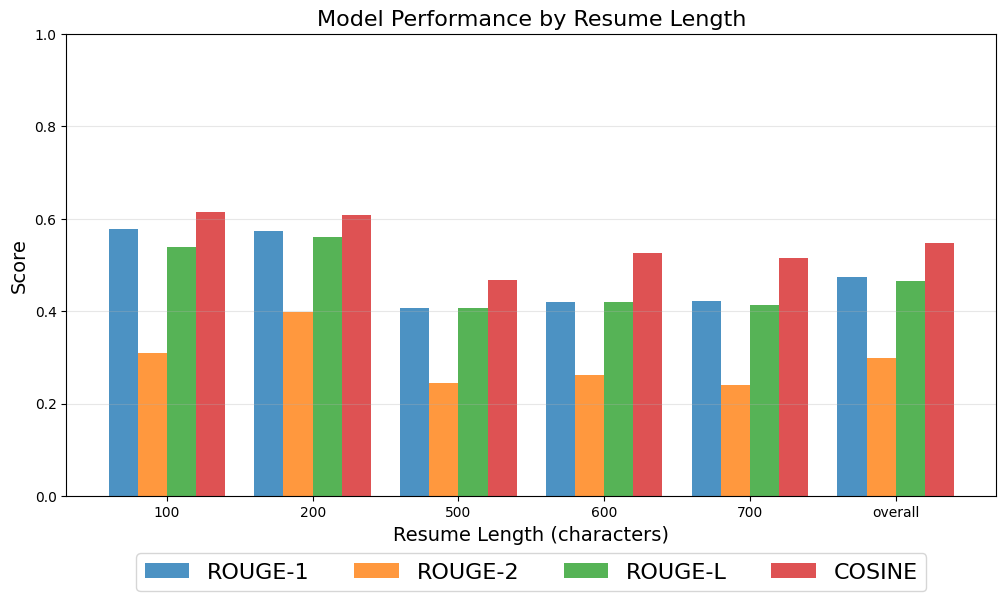

In [14]:
main()